## Load modules

In [1]:
import xarray as xr
import numpy as np
import cdo
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Functions

In [2]:
# Define NEMO coastal mask of the area to parametrised
# method:
# - reverse the cell_to_param mask
# - detect contour
# - pick from contour only the ocean points
def get_coastal_msk(mask_in,lewp):
    nj_out=mask_in.shape[0]
    ni_out=mask_in.shape[1]

    if lewp:
        mask=np.zeros(shape=(nj_out,ni_out+2))
        mask[:,1:-1]=mask_in
        mask[:, 0]=mask[:,-2]
        mask[:,-1]=mask[:, 1]
        xslc=slice(0,ni_out)
    else:
        mask=mask_in
        xslc=slice(1,-1)
        
    mask_coast=np.zeros(shape=(nj_out,ni_out))
    mask_coast[1:-1,xslc]= ( mask[1:-1,1:-1] + 
                             mask[0:-2,1:-1] + mask[2::,1:-1] + mask[1:-1,0:-2] + mask[1:-1,2::] +
                             mask[0:-2,0:-2] + mask[2::,2::]  + mask[2::,0:-2]  + mask[0:-2,2::] ) * mask[1:-1,1:-1]
    mask_coast[(mask_coast > 1) & (mask_coast < 9)] = 10
    mask_coast[mask_coast!=10]=np.nan
    mask_coast=mask_coast.astype(np.float32)
    mask_coast[mask_coast==10]=1
    
    return mask_coast

## Initialisation cdo

In [3]:
cdo = cdo.Cdo()

## Load Bedmachine data and grids

In [4]:
# Load ice shelf melt rate data
ds_bm_basins = xr.open_dataset('Mask_Iceshelf_IMBIE2_cdo.nc')
cvar_basins='Iceshelf_extrap'
da_bm_basins=ds_bm_basins[cvar_basins].values.squeeze()

# Bedmachine state data
fbm_data='BedMachine_v3_aggregated2km_allvars_cut.nc'
ds_bm=xr.open_dataset(fbm_data)
cvar_isffrac='isf_conc'

# flip bedmachine data in y direction to IMBIE2 convention
ds_bm = ds_bm.isel(y=slice(None, None, -1))

# add bounds to bedmachine data for nco interpolation
ds_bm = ds_bm.assign_coords(lat_bnds=ds_bm_basins['lat_bnds'], 
                            lon_bnds=ds_bm_basins['lon_bnds'],
                            lat=ds_bm_basins['lat'],
                            lon=ds_bm_basins['lon'])

## Load NEMO data and grids

In [5]:
## target grid
fNEMO_grid = 'grid_O2_NEMO4.2_CDO.nc'
ds_nemo_grid=xr.open_dataset(fNEMO_grid)

# Read domain_cfg.nc
ds_nemo=xr.open_dataset('domain_cfg_O2.nc')
NEMO_isfd=ds_nemo.top_level.squeeze()
NEMO_area=(ds_nemo.e1t*ds_nemo.e2t).squeeze()

# get NEMO mask
NEMO_mask=ds_nemo.bottom_level.squeeze()
NEMO_mask=np.where(NEMO_mask>0,1,0)
NEMO_mask[30::,:]=1 # => specific to ORCA2

# get coastal cells
NEMO_mask_coast=-np.zeros(shape=NEMO_mask.shape)
NEMO_mask_coast=get_coastal_msk(NEMO_mask,True)
NEMO_mask_coast[np.isnan(NEMO_mask_coast) | (NEMO_mask==0)]=-1

# compute area not resolved by NEMO
**Method:**
- conservative interpolation of Elmer floating cell to NEMO
- set to 1 value between 0 and 1 (ie area to parametrised in NEMO)
- conservative interpolation back to ELMER to give the cell that need to be included in the param and the area scale factor

In [6]:
## CDO inperpolation
### cdo.remapcon(f'{target_grid}',input=input_xrdataset, returnArray=variable_name_to_process)
NEMO_isffrac=cdo.remapcon(f'{fNEMO_grid}', input=ds_bm, returnArray=cvar_isffrac, env={"CDO_REMAP_NORM": "areafrac"}).squeeze()
NEMO_isffrac[0,50:60]=1 # => specific to ORCA2

# set to 1 cell to parametrised
NEMO_cell_to_param=np.zeros(shape=NEMO_isffrac.shape)
NEMO_cell_to_param=np.where((NEMO_isffrac > 0) & (NEMO_isffrac<=1),1,0)

# Define the cell where to activate the param in NEMO

Maybe this need to be done before the reinterpolation back to ELMER and the draft distribution.
 * compute list of basin from the NEMO_mask_param_basins variables
 * mask the missing basin in the NEMO_basins variable
 * do a nn extrapolation on the NEMO grid
 * interpolate back to ELMER
 * compute the isf draft distribution

## Interpolation of basin variable from Bedmachine grid to NEMO grid
**Method:** cdo nearest neighbourg

**Warning** : 
 * possibly this need to be move after the domain cfg computation
 * why not use the extrapolate basin file on stereo ?

In [7]:
## CDO inperpolation
NEMO_basins=cdo.remapnn(f'{fNEMO_grid}',input=ds_bm_basins[[cvar_basins]], returnArray=cvar_basins).squeeze()

## Get all the basins id mask along the 'coastal' band

In [8]:
# get basin number for each coastal cell
NEMO_mask_param_basins=np.where((NEMO_mask_coast >= 0), NEMO_basins, -1)

In [9]:
# get list of ID avalable in NEMO along the 'coastal' band
NEMO_basins_list = np.unique(NEMO_mask_param_basins[NEMO_mask_param_basins >= 0]).astype(int)

# get list of ID avalable in BedMachine with basal melt values
ANT_basins_list = np.unique(da_bm_basins).astype(int)
ANT_basins_list_with_mlt_in_NEMO=[]
ANT_basins_list_with_no_trg_in_NEMO=[]


# get list of basin with basal melt values in Rignot et al. 2013 but not in NEMO
RED = "\033[31m"
RESET = "\033[0m"
nbas=0
rmiss=0.0
print(f'Basin not in NEMO but with melt in Rignot et al. 2013:')
for ibasin,basin in enumerate(ds_bm_basins.ID.values):
    name=ds_bm_basins.NAME[ibasin].values
    if ds_bm_basins.MeltRignot[ibasin] != 0 and basin not in NEMO_basins_list:
        nbas+=1
        rmiss+=ds_bm_basins.MeltRignot[ibasin].values
        ANT_basins_list_with_no_trg_in_NEMO.append(basin)
        print(f'{RED}        Basin {basin:3d} ({name:25s}) is in ANT but not in NEMO ({ds_bm_basins.MeltRignot[ibasin].values:.2f} Gt/yr) {RESET}')
    elif ds_bm_basins.MeltRignot[ibasin] != 0 and basin in NEMO_basins_list:
        print(f'    Basin {basin:3d} ({name:25s}): {ds_bm_basins.MeltRignot[ibasin].values:.2f} Gt/yr is in both ANT and NEMO')
        ANT_basins_list_with_mlt_in_NEMO.append(basin)
    elif ds_bm_basins.MeltRignot[ibasin] == 0 and basin in NEMO_basins_list:
        print(f'    Basin {basin:3d} ({name:25s}): in NEMO but no melt in Rignot et al. 2013')

print('')
if nbas==0:
    print('All basins with melt in Rignot et al. 2013 are in NEMO')
else:
    print(f'{nbas} basins that represent {rmiss:.2f} Gt/yr are not in NEMO')


Basin not in NEMO but with melt in Rignot et al. 2013:
    Basin   1 (Jelbart                  ): -1.00 Gt/yr is in both ANT and NEMO
    Basin   2 (Fimbul                   ): 23.50 Gt/yr is in both ANT and NEMO
    Basin   4 (Vigrid                   ): 3.20 Gt/yr is in both ANT and NEMO
    Basin   5 (Nivl                     ): 3.90 Gt/yr is in both ANT and NEMO
    Basin   7 (Lazarev                  ): 6.30 Gt/yr is in both ANT and NEMO
    Basin   8 (Borchgrevink             ): 7.50 Gt/yr is in both ANT and NEMO
    Basin   9 (Baudouin                 ): 14.10 Gt/yr is in both ANT and NEMO
    Basin  10 (                         ): in NEMO but no melt in Rignot et al. 2013
    Basin  11 (Prince_Harald            ): -2.00 Gt/yr is in both ANT and NEMO
        Basin  13 (Shirase                  ) is in ANT but not in NEMO (5.70 Gt/yr) 
    Basin  14 (Hannan/Telen/Skallen     ): in NEMO but no melt in Rignot et al. 2013
        Basin  15 (Rayner_Thyer             ) is in ANT but n

### Redistribute this in other basins with melt in Rignot et al. 2013 and present in NEMO

In [10]:
#ORCA2 specific redirection of basins to be parametrised
redirection={}
redirection[13]=11 # Shirase           to Prince_Harald 
redirection[15]=16 # Rayner_Thyer      to Porter
redirection[17]=16 # WilmaRobertDowner to Porter
redirection[18]=16 # Edward_VIII       to Porter

redirection[22]=21 # Publication       to Amery
redirection[31]=30 # Vincenne          to unnamed ice shelf
redirection[55]=53 # Lillies           to Rennick ice shelf

redirection[84]=85 # Crosson           to Thwaites
redirection[86]=85 # Pine Island       to Thwaites
redirection[88]=89 # CosGrove          to unnamed ice shelf

redirection[94] =97  # Ferrigno to Rydberg_Peninsula
redirection[99] =98  # GeorgeVI to Stange
redirection[101]=102 # Bach to unnamed ice shelf
redirection[112]=110 # Wordie to unnamed ice shelf

redirection[121]=122 # Larsen F to ClarkeBay
redirection[123]=122 # Larsen G to ClarkeBay

redirection[133]=132 # Atka to Ekstrom

# check redirection (target basin in NEMO and with melt in Rignot et al. 2013)
for k,v in redirection.items():
    if v not in NEMO_basins_list:
        print(f'{RED}Error: target basin {v} for redirection of basin {k} is not in NEMO{RESET}')
    else:
        print(f'Basin {k} is redirected to basin {v}')
        if v not in ANT_basins_list_with_mlt_in_NEMO:
            ANT_basins_list_with_mlt_in_NEMO.append(np.int64(v))

# check list of item = ANT_basins_list_with_no_trg_in_NEMO
for basin in ANT_basins_list_with_no_trg_in_NEMO:
    if basin not in redirection.keys():
        print(f'{RED}Error: basin {basin} with melt in Rignot et al. 2013 but not in NEMO is not redirected{RESET}')
        
# set to 0 the coastal cell that are not in ANT basins list
NEMO_mask_param_basins=np.where(np.isin(NEMO_mask_param_basins, ANT_basins_list_with_mlt_in_NEMO), NEMO_mask_param_basins, -1)

Basin 13 is redirected to basin 11
Basin 15 is redirected to basin 16
Basin 17 is redirected to basin 16
Basin 18 is redirected to basin 16
Basin 22 is redirected to basin 21
Basin 31 is redirected to basin 30
Basin 55 is redirected to basin 53
Basin 84 is redirected to basin 85
Basin 86 is redirected to basin 85
Basin 88 is redirected to basin 89
Basin 94 is redirected to basin 97
Basin 99 is redirected to basin 98
Basin 101 is redirected to basin 102
Basin 112 is redirected to basin 110
Basin 121 is redirected to basin 122
Basin 123 is redirected to basin 122
Basin 133 is redirected to basin 132


### Compute zmin and zmax

In [20]:
zmin_basin = [None]*len(ds_bm_basins.ID.values)
zmax_basin = [None]*len(ds_bm_basins.ID.values)

print('Data for basin in NEMO:')
for ibasin,basin in enumerate(ds_bm_basins.ID.values):

    # Select the cells in the current basin
    mask = ((da_bm_basins == basin) & (ds_bm[cvar_isffrac] > 0))  # Only consider cells with ice shelf presence
    valid_draft = (ds_bm['thickness'].values[mask] - ds_bm['surface'].values[mask])  # Make draft positive down

    if len(valid_draft) > 0:
        zmin_basin[ibasin] = max(np.percentile(valid_draft, 25), 20.) # enforce that zmin is not too shallow
        zmax_basin[ibasin] = max(np.percentile(valid_draft, 99), 20.) # enforce that zmax is not too shallow
    else:
        zmin_basin[ibasin] = np.nan
        zmax_basin[ibasin] = np.nan
        if ds_bm_basins.MeltRignot[ibasin] != 0 and basin in ANT_basins_list_with_mlt_in_NEMO:
            print(f'{RED}Warning: Basin {basin:3d} ({ds_bm_basins.NAME[ibasin].values:25s}) has no valid draft data in BedMachine{RESET}')

    # print data for basin in NEMO
    if basin in ANT_basins_list_with_mlt_in_NEMO:
        print(f'Basin {basin:3d} ({ds_bm_basins.NAME[ibasin].values:25s}): zmin={zmin_basin[ibasin]:>6.1f} m, zmax={zmax_basin[ibasin]:>6.1f} m, melt={ds_bm_basins.MeltRignot[ibasin].values:.2f} Gt/yr')

# No redirection for zmin and zmax, keep the one from the target.

Data for basin in NEMO:
Basin   1 (Jelbart                  ): zmin= 297.2 m, zmax= 825.7 m, melt=-1.00 Gt/yr
Basin   2 (Fimbul                   ): zmin= 202.0 m, zmax= 728.6 m, melt=23.50 Gt/yr
Basin   4 (Vigrid                   ): zmin= 308.1 m, zmax= 565.1 m, melt=3.20 Gt/yr
Basin   5 (Nivl                     ): zmin= 203.1 m, zmax= 532.0 m, melt=3.90 Gt/yr
Basin   7 (Lazarev                  ): zmin= 151.5 m, zmax= 456.4 m, melt=6.30 Gt/yr
Basin   8 (Borchgrevink             ): zmin= 229.2 m, zmax= 672.0 m, melt=7.50 Gt/yr
Basin   9 (Baudouin                 ): zmin= 197.0 m, zmax= 475.4 m, melt=14.10 Gt/yr
Basin  11 (Prince_Harald            ): zmin= 150.7 m, zmax= 510.5 m, melt=-2.00 Gt/yr
Basin  16 (Zubchatyy/Porter/Myers   ): zmin=  86.3 m, zmax= 572.2 m, melt=0.00 Gt/yr
Basin  21 (Amery                    ): zmin= 312.1 m, zmax=1829.3 m, melt=35.50 Gt/yr
Basin  24 (West                     ): zmin= 216.8 m, zmax= 642.0 m, melt=27.20 Gt/yr
Basin  26 (Shackleton              

In [12]:
zmin_map = np.full_like(NEMO_mask_param_basins, 0, dtype=np.float64)
zmax_map = np.full_like(NEMO_mask_param_basins, 0, dtype=np.float64)

for ibasin,basin in enumerate(ANT_basins_list):
    if basin in ANT_basins_list_with_mlt_in_NEMO:
        zmin_map[NEMO_mask_param_basins == basin] = zmin_basin[ibasin]
        zmax_map[NEMO_mask_param_basins == basin] = zmax_basin[ibasin]

### Compute melt rate

In [13]:
zmelt_map = np.full_like(NEMO_mask_param_basins, 0, dtype=np.float64)
for ibasin,basin in enumerate(ANT_basins_list):
    if basin in ANT_basins_list_with_mlt_in_NEMO:
        zmelt_map[NEMO_mask_param_basins == basin] = ds_bm_basins.MeltRignot.values[ibasin]*1.e9*1.e3/(86400.*365.)/np.sum(NEMO_area.values[NEMO_mask_param_basins == basin],dtype=np.double) # convert Gt/yr to kg/m2/s
        print(f'Basin {basin:3d} ({ds_bm_basins.NAME[ibasin].values:25s}): melt={ds_bm_basins.MeltRignot[ibasin].values:.2f} Gt/yr, zmelt={zmelt_map[NEMO_mask_param_basins == basin][0]:.2e} kg/m2/s')

# now apply redirection
for ibasin,basin in enumerate(ds_bm_basins.ID.values):
    if basin in redirection.keys():
        print(f'Applying redirection of basin {basin} to basin {redirection[basin]}')
        zmelt_map[NEMO_mask_param_basins == redirection[basin]] = zmelt_map[NEMO_mask_param_basins == redirection[basin]] + ds_bm_basins.MeltRignot.values[ibasin]*1.e9*1.e3/(86400.*365.)/np.sum(NEMO_area.values[NEMO_mask_param_basins == redirection[basin]]) # convert Gt/yr to kg/m2/s

Basin   1 (Jelbart                  ): melt=-1.00 Gt/yr, zmelt=-2.79e-06 kg/m2/s
Basin   2 (Fimbul                   ): melt=23.50 Gt/yr, zmelt=2.09e-05 kg/m2/s
Basin   4 (Vigrid                   ): melt=3.20 Gt/yr, zmelt=1.67e-05 kg/m2/s
Basin   5 (Nivl                     ): melt=3.90 Gt/yr, zmelt=1.02e-05 kg/m2/s
Basin   7 (Lazarev                  ): melt=6.30 Gt/yr, zmelt=1.65e-05 kg/m2/s
Basin   8 (Borchgrevink             ): melt=7.50 Gt/yr, zmelt=1.31e-05 kg/m2/s
Basin   9 (Baudouin                 ): melt=14.10 Gt/yr, zmelt=1.44e-05 kg/m2/s
Basin  11 (Prince_Harald            ): melt=-2.00 Gt/yr, zmelt=-3.27e-06 kg/m2/s
Basin  16 (Zubchatyy/Porter/Myers   ): melt=0.00 Gt/yr, zmelt=0.00e+00 kg/m2/s
Basin  21 (Amery                    ): melt=35.50 Gt/yr, zmelt=5.67e-05 kg/m2/s
Basin  24 (West                     ): melt=27.20 Gt/yr, zmelt=1.55e-05 kg/m2/s
Basin  26 (Shackleton               ): melt=72.60 Gt/yr, zmelt=5.22e-05 kg/m2/s
Basin  27 (Tracy_Tremenchus         ): melt

## Define the output file

In [14]:
# Compute global min/max for each variable
zmin_global_min = float(np.nanmin(zmin_map))
zmin_global_max = float(np.nanmax(zmin_map))
zmax_global_min = float(np.nanmin(zmax_map))
zmax_global_max = float(np.nanmax(zmax_map))

melt_global_min = float(np.nanmin(zmelt_map))
melt_global_max = float(np.nanmax(zmelt_map))

param_id_min = int(np.nanmin(NEMO_mask_param_basins))
param_id_max = int(np.nanmax(NEMO_mask_param_basins))

# Create dataset for output
ds_out = xr.Dataset(
    data_vars=dict(
        isf_param_id=(["x", "y"], NEMO_mask_param_basins.astype(np.int32), dict(
            units='1',
            long_name='ice shelf parameterization basin ID',
            valid_min=param_id_min,
            valid_max=param_id_max
        )),
        
        isf_zmin=(["x", "y"], zmin_map, dict(
            units='m',
            long_name='ice shelf minimum draft depth (25th percentile)',
            valid_min=zmin_global_min,
            valid_max=zmin_global_max
        )),

        isf_melt=(["x", "y"], zmelt_map, dict(
            units='kg/m2/s',
            long_name='ice shelf melt rate (from Rignot et al. 2013)',
            valid_min=melt_global_min,
            valid_max=melt_global_max
        )),
        
        isf_zmax=(["x", "y"], zmax_map, dict(
            units='m',
            long_name='ice shelf maximum draft depth (99th percentile)',
            valid_min=zmax_global_min,
            valid_max=zmax_global_max
        )),
    ),
    
    coords=dict(
        lon=(["x", "y"], ds_nemo.glamt.values.squeeze(), dict(
            units='degrees_east',
            long_name='longitude'
        )),
        lat=(["x", "y"], ds_nemo.gphit.values.squeeze(), dict(
            units='degrees_north',
            long_name='latitude'
        )),

        basin=(["id"], np.array(list(ANT_basins_list_with_mlt_in_NEMO)).astype(np.int32), dict(
            long_name='list of unique basin IDs'
        )),
    ),
)

# Save to NetCDF
ds_out.to_netcdf('isf_param.nc')


## Check Output file
### total melt for each ice shelf as in Rignot et al. 2013

In [15]:

ds_check = xr.open_dataset('isf_param.nc')
isf_param_id = ds_check['isf_param_id'].values
isf_zmin = ds_check['isf_zmin'].values
isf_zmax = ds_check['isf_zmax'].values
isf_melt = ds_check['isf_melt'].values
isf_id = ds_check['basin'].values  

for ibasin,basin in enumerate(isf_id):
    melt_value = np.sum(isf_melt[isf_param_id == basin]*NEMO_area.values[isf_param_id == basin],dtype=np.double)*(86400.*365.)/(1.e9*1.e3) # convert back to Gt/yr
    zmin_value = np.max(isf_zmin[isf_param_id == basin])
    zmax_value = np.max(isf_zmax[isf_param_id == basin])
    Rignot_melt = ds_bm_basins.MeltRignot.values[ds_bm_basins.ID.values == basin][0]
    name=ds_bm_basins.NAME.values[ds_bm_basins.ID.values == basin][0]
    err=melt_value-Rignot_melt
    if np.abs(err) >= 1e-10:
        print(f'Basin {basin:3d} ({name:25s}): melt={melt_value:.2f} (obs:{Rignot_melt:.2f}) Gt/y, zmin={zmin_value:.1f} m, zmax={zmax_value:.1f} m, err={err} Gt/yr')
        #check it match the redirection if any
        if basin in redirection.values():
            redirected_from = [k for k,v in redirection.items() if v == basin]
            redirected_melt = sum(ds_bm_basins.MeltRignot.values[ds_bm_basins.ID.values == k][0] for k in redirected_from)
            if np.abs(melt_value - (Rignot_melt + redirected_melt)) >= 1e-10:
                print(f'{RED}    Redirection check failed: melt={melt_value:.2f} Gt/y, expected {(Rignot_melt + redirected_melt):.2f} Gt/y (obs:{Rignot_melt:.2f} + redirected:{redirected_melt:.2f}) Gt/yr {RESET}')
            else:
                print(f'    Redirection check passed: melt={melt_value:.2f} Gt/y, expected {(Rignot_melt + redirected_melt):.2f} Gt/y (obs:{Rignot_melt:.2f} + redirected:{redirected_melt:.2f}) Gt/yr')

Basin  11 (Prince_Harald            ): melt=3.70 (obs:-2.00) Gt/y, zmin=150.7 m, zmax=510.5 m, err=5.7 Gt/yr
    Redirection check passed: melt=3.70 Gt/y, expected 3.70 Gt/y (obs:-2.00 + redirected:5.70) Gt/yr
Basin  21 (Amery                    ): melt=37.00 (obs:35.50) Gt/y, zmin=312.1 m, zmax=1829.3 m, err=1.499999999999993 Gt/yr
    Redirection check passed: melt=37.00 Gt/y, expected 37.00 Gt/y (obs:35.50 + redirected:1.50) Gt/yr
Basin  53 (Rennick                  ): melt=10.40 (obs:7.00) Gt/y, zmin=174.6 m, zmax=958.6 m, err=3.4000000000000004 Gt/yr
    Redirection check passed: melt=10.40 Gt/y, expected 10.40 Gt/y (obs:7.00 + redirected:3.40) Gt/yr
Basin  85 (Thwaites                 ): melt=237.20 (obs:97.50) Gt/y, zmin=266.0 m, zmax=966.8 m, err=139.7 Gt/yr
    Redirection check passed: melt=237.20 Gt/y, expected 237.20 Gt/y (obs:97.50 + redirected:139.70) Gt/yr
Basin  98 (Stange                   ): melt=117.00 (obs:28.00) Gt/y, zmin=110.2 m, zmax=580.8 m, err=88.999999999999

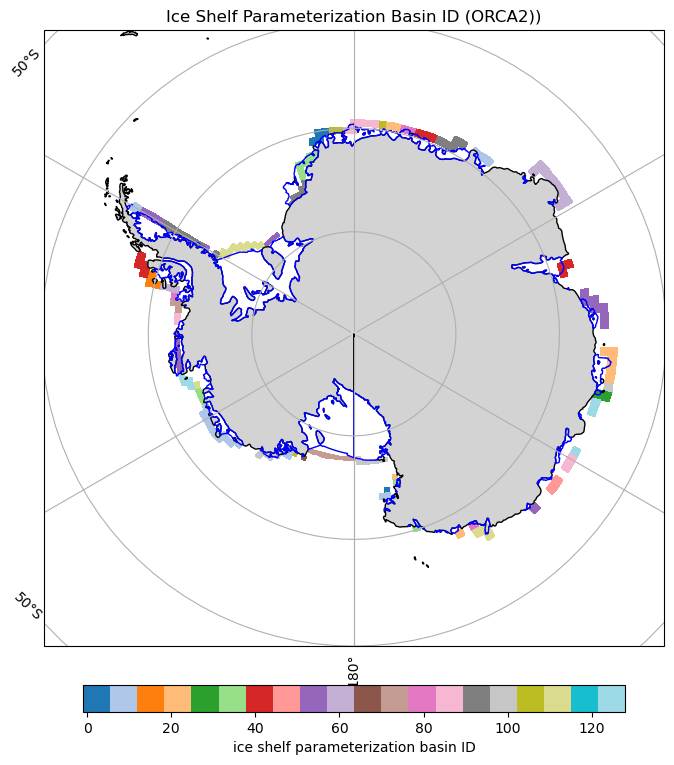

In [16]:
# Load your dataset
ds = xr.open_dataset('isf_param.nc')

# Extract data
param_id = ds['isf_param_id']
lon = ds['lon']
lat = ds['lat']

# Identifier les ID valides (1 à 84)
valid_ids = np.arange(1, 130)

# Créer une permutation aléatoire des ID
shuffled_ids = np.random.permutation(valid_ids)

# Construire un dictionnaire de remappage
remap_dict = dict(zip(valid_ids, shuffled_ids))

# Appliquer le remappage sur une copie
param_id_shuffled = np.full_like(param_id, fill_value=-1)
for old_id, new_id in remap_dict.items():
    param_id_shuffled[param_id == old_id] = new_id


# Mask bad values (-1)
param_id_masked = np.ma.masked_where(param_id.values <= 0, param_id_shuffled)

# Set up projection
proj = ccrs.SouthPolarStereo()  # EPSG:3031

# Create figure and axis
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Add land and ice shelves using Natural Earth features
land = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black', facecolor='lightgray')
ice_shelves = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',
                                           edgecolor='blue', facecolor='none')

ax.add_feature(land, zorder=1)
ax.add_feature(ice_shelves, zorder=2)

# Plot the param_id map
c = ax.pcolormesh(lon, lat, param_id_masked,
                  transform=ccrs.PlateCarree(),
                  cmap='tab20', shading='auto', zorder=0)

# Add colorbar
cb = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cb.set_label(param_id.long_name)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

plt.title('Ice Shelf Parameterization Basin ID (ORCA2))')
#plt.tight_layout()
#
fig.savefig('basin_id_map.png', dpi=150, bbox_inches='tight', transparent=False)